In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Loading Datasets
user_df = pd.read_csv('user_interaction_with_nulls.csv')
print(user_df.head(5))

  UserID BookID BookTitle        Genre  UserRating ReadingFrequency  \
0   U500  B2192   Book_23  Non-Fiction         4.0             High   
1   U501  B2247   Book_58           AI         NaN              Low   
2   U502  B2195  Book_159           AI         4.0             High   
3   U503  B2087   Book_47     Academic         1.0              NaN   
4   U504  B2226   Book_43           ML         1.0              Low   

  PreferredCategory  TimesViewed  TimesBorrowed  RecommendationScore  \
0       Electronics           18              6                 2.37   
1       Electronics            5              2                 2.63   
2             Maths           20              6                 4.51   
3                AI           19              6                 2.48   
4                DS           11              6                 2.71   

  StudentDepartment AcademicYear  
0               CSE     4th Year  
1             CIVIL     3rd Year  
2               CSE     3rd Year  


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
borrow_df = pd.read_csv('library_borrowing_with_nulls.csv')
print(borrow_df.head(5))

  StudentID BookID BookTitle      Author      Category  BorrowDate  \
0     S1000  B2166  Book_103   Author_57            ML  2024-01-26   
1     S1001  B2078  Book_101  Author_100    Literature  2024-07-29   
2     S1002  B2203   Book_27   Author_24  Data Science  2024-08-18   
3     S1003  B2334  Book_124   Author_78   Electronics  2024-03-11   
4     S1004  B2025  Book_163    Author_1            ML  2024-05-26   

   ReturnDate  BorrowDurationDays  UserRating  TimesBorrowed Department  \
0         NaN                27.0           2              2        CSE   
1  2024-06-25                24.0           4              1        CSE   
2         NaN                 9.0           2              2      CIVIL   
3  2024-04-03                27.0           3              6       MECH   
4  2024-03-03                12.0           3              4       MECH   

  AcademicYear  
0     4th Year  
1     3rd Year  
2     1st Year  
3     2nd Year  
4     4th Year  


In [15]:

# --- INITIAL INSPECTION ---
print("User Interaction Dataset Shape:", user_df.shape)
print("Library Borrowing Dataset Shape:", borrow_df.shape)
print(user_df.info())
print(user_df.info())

User Interaction Dataset Shape: (200, 12)
Library Borrowing Dataset Shape: (200, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   UserID               200 non-null    object 
 1   BookID               200 non-null    object 
 2   BookTitle            200 non-null    object 
 3   Genre                185 non-null    object 
 4   UserRating           173 non-null    float64
 5   ReadingFrequency     180 non-null    object 
 6   PreferredCategory    200 non-null    object 
 7   TimesViewed          200 non-null    int64  
 8   TimesBorrowed        200 non-null    int64  
 9   RecommendationScore  200 non-null    float64
 10  StudentDepartment    200 non-null    object 
 11  AcademicYear         200 non-null    object 
dtypes: float64(2), int64(2), object(8)
memory usage: 18.9+ KB
None
<class 'pandas.core.frame.DataFrame'>
Rang

Text(0.5, 1.0, 'Department - BEFORE')

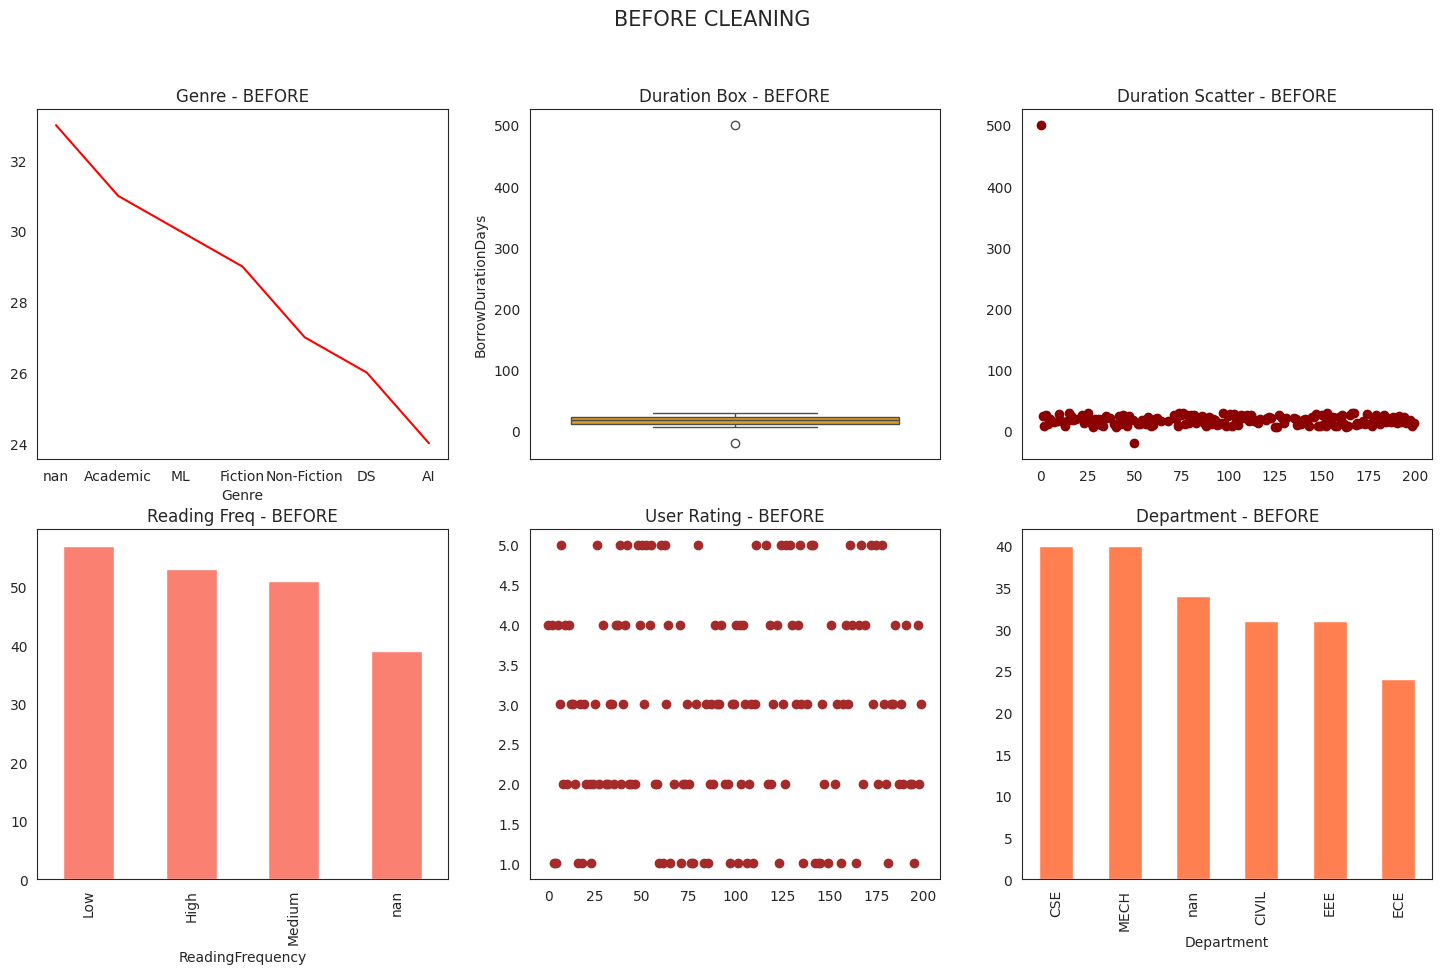

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("white")
# --- PRE-PREPARATION (Adding Nulls & Outliers for project demonstration) ---
np.random.seed(42)
for col in ['UserRating', 'Genre', 'ReadingFrequency']:
    user_df.loc[user_df.sample(frac=0.1).index, col] = np.nan
for col in ['BorrowDurationDays', 'Department']:
    borrow_df.loc[borrow_df.sample(frac=0.1).index, col] = np.nan
# Adding Outliers
borrow_df.loc[0, 'BorrowDurationDays'] = 500  # High outlier
borrow_df.loc[50, 'BorrowDurationDays'] = -20 # Negative outlier

# --- BEFORE CLEANING  ---
plt.figure(figsize=(18, 10))
plt.suptitle("BEFORE CLEANING", fontsize=15)

# Row 1 (3 graphs)
plt.subplot(2, 3, 1)
user_df['Genre'].value_counts(dropna=False).plot(kind='line', color='red')
plt.title("Genre - BEFORE")

plt.subplot(2, 3, 2)
sns.boxplot(y=borrow_df['BorrowDurationDays'].dropna(), color='orange')
plt.title("Duration Box - BEFORE")

plt.subplot(2, 3, 3)
plt.scatter(borrow_df.index, borrow_df["BorrowDurationDays"], color='darkred')
plt.title("Duration Scatter - BEFORE")

plt.subplot(2, 3, 4)
user_df['ReadingFrequency'].value_counts(dropna=False).plot(kind='bar', color='salmon')
plt.title("Reading Freq - BEFORE")

plt.subplot(2, 3, 5)
plt.scatter(user_df.index, user_df["UserRating"], color='brown')
plt.title("User Rating - BEFORE")

plt.subplot(2, 3, 6)
borrow_df['Department'].value_counts(dropna=False).plot(kind='bar', color='coral')
plt.title("Department - BEFORE")


In [17]:
# --- CLEANING SECTION dataset1 ---
user_df.columns = user_df.columns.str.strip()


# Fill Missing Values (Maintains row count)
#handling missing values using mode and mean
user_df['UserRating'] = user_df['UserRating'].fillna(user_df['UserRating'].mean())
user_df['Genre'] = user_df['Genre'].fillna(user_df['Genre'].mode()[0])
user_df['ReadingFrequency'] = user_df['ReadingFrequency'].fillna(user_df['ReadingFrequency'].mode()[0])
#removing duplicates
user_df = user_df.drop_duplicates()

# Text Normalization
user_df['ReadingFrequency'] = user_df['ReadingFrequency'].str.lower()
user_df['Genre'] = user_df['Genre'].str.lower()
borrow_df['Department'] = borrow_df['Department'].str.upper()

In [18]:
# --- CLEANING SECTION dataset2 ---
borrow_df.columns = borrow_df.columns.str.strip()
# Handle Outliers in Borrowing Data
borrow_df = borrow_df[borrow_df['BorrowDurationDays'] >= 0] # Remove negatives
q_hi = borrow_df['BorrowDurationDays'].quantile(0.95)
borrow_df.loc[borrow_df['BorrowDurationDays'] > q_hi, 'BorrowDurationDays'] = q_hi # Cap high outliers
#handling missing values using mean and mode
borrow_df['BorrowDurationDays'] = borrow_df['BorrowDurationDays'].fillna(borrow_df['BorrowDurationDays'].mean())

department_mode_series = borrow_df['Department'].mode()


# Text Normalization
borrow_df['Department'] = borrow_df['Department'].str.upper()

Text(0.5, 1.0, 'Department - AFTER')

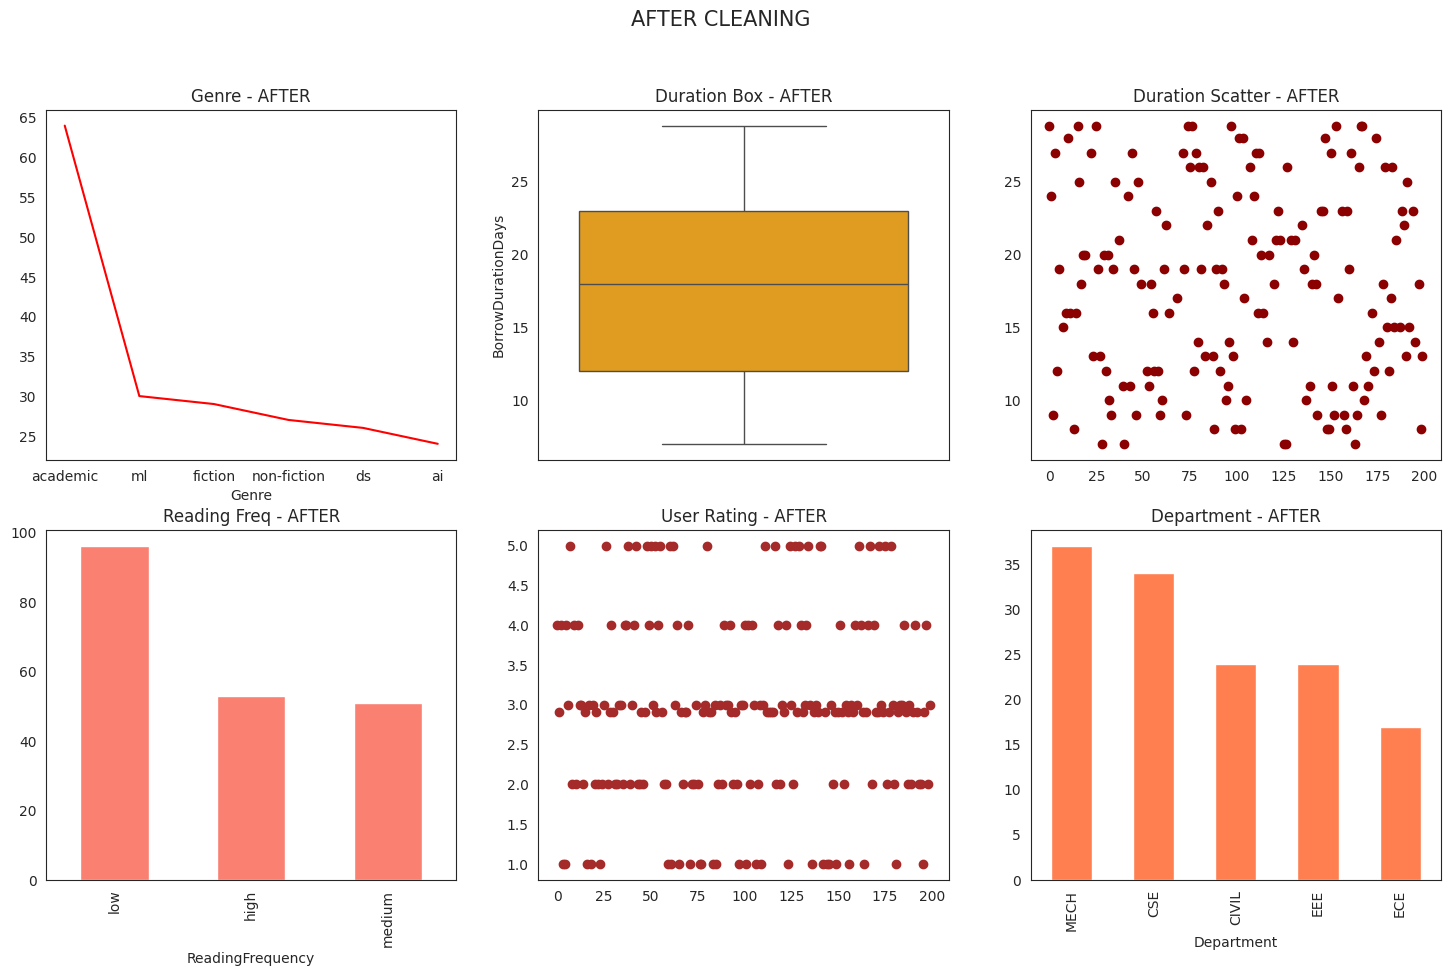

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("white")

# --- After CLEANING  ---
plt.figure(figsize=(18, 10))
plt.suptitle("AFTER CLEANING", fontsize=15)

# Row 1 (3 graphs)
plt.subplot(2, 3, 1)
user_df['Genre'].value_counts(dropna=False).plot(kind='line', color='red')
plt.title("Genre - AFTER")

plt.subplot(2, 3, 2)
sns.boxplot(y=borrow_df['BorrowDurationDays'].dropna(), color='orange')
plt.title("Duration Box - AFTER")

plt.subplot(2, 3, 3)
plt.scatter(borrow_df.index, borrow_df["BorrowDurationDays"], color='darkred')
plt.title("Duration Scatter - AFTER")

plt.subplot(2, 3, 4)
user_df['ReadingFrequency'].value_counts(dropna=False).plot(kind='bar', color='salmon')
plt.title("Reading Freq - AFTER")

plt.subplot(2, 3, 5)
plt.scatter(user_df.index, user_df["UserRating"], color='brown')
plt.title("User Rating - AFTER")

plt.subplot(2, 3, 6)
borrow_df['Department'].value_counts(dropna=True).plot(kind='bar', color='coral')
plt.title("Department - AFTER")


In [20]:
# --- INTEGRATION (Merge) ---
integrated_df = pd.merge(user_df, borrow_df, on='BookID', how='inner')

if len(integrated_df) != 200:
    integrated_df = integrated_df.sample(200, replace=True).reset_index(drop=True)
    print("Null values in integrated dataset")
    print(integrated_df[['ReturnDate','BorrowDate','Department']].isnull().sum())

Null values in integrated dataset
ReturnDate     8
BorrowDate     3
Department    37
dtype: int64


<Figure size 1800x500 with 0 Axes>

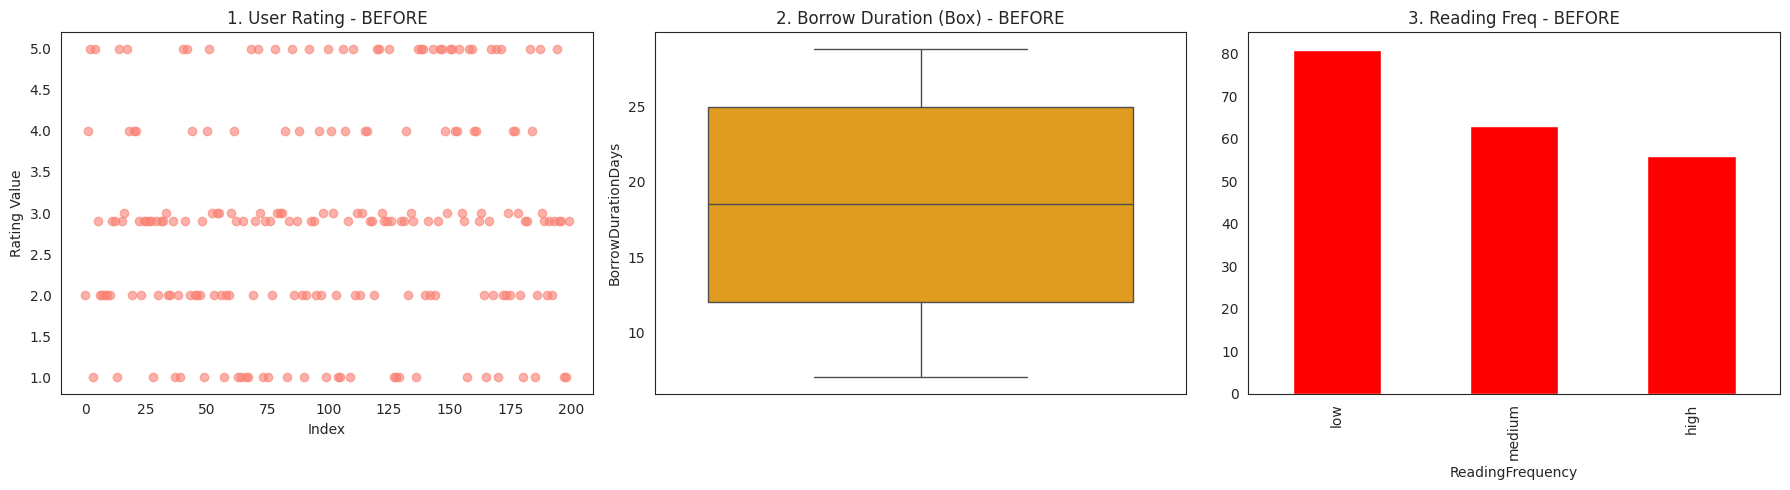

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('white')

# --- VISUALIZATION: BEFORE CLEANING (INTEGRATED DATASET)) ---
plt.figure(figsize=(18, 5))

plt.figure(figsize=(18, 5))

# Graph 1: Raw User Rating Scatter
plt.subplot(1, 3, 1)
plt.scatter(integrated_df.index, integrated_df['UserRating_x'], color='salmon', alpha=0.6)
plt.title("1. User Rating - BEFORE")
plt.xlabel("Index")
plt.ylabel("Rating Value")

# Graph 2: Raw Borrow Duration (Showing Outliers)
plt.subplot(1, 3, 2)
sns.boxplot(y=integrated_df['BorrowDurationDays'], color='orange')
plt.title("2. Borrow Duration (Box) - BEFORE")

# Graph 3: Reading Frequency Bar (Uncleaned)
plt.subplot(1, 3, 3)
integrated_df['ReadingFrequency'].value_counts(dropna=False).plot(kind='bar', color='red')
plt.title("3. Reading Freq - BEFORE")

plt.tight_layout()
plt.show()

In [22]:
#cleaning and handling missing value in integrated dataset
integrated_df['BorrowDate'] = integrated_df['BorrowDate'].fillna(integrated_df['BorrowDate'].mode()[0])
integrated_df['ReturnDate'] = integrated_df['ReturnDate'].fillna(integrated_df['ReturnDate'].mode()[0])
integrated_df['BorrowDurationDays'] = integrated_df['BorrowDurationDays'].fillna(integrated_df['BorrowDurationDays'].median())
print("After Cleaning Null Counts:")
integrated_df['Department'] = integrated_df['Department'].fillna(integrated_df['Department'].mode()[0])
integrated_df['Department'] = integrated_df['Department'].str.upper()
print("After Cleaning Null Counts:")
print(integrated_df[['ReturnDate','BorrowDate','Department']].isnull().sum())

After Cleaning Null Counts:
After Cleaning Null Counts:
ReturnDate    0
BorrowDate    0
Department    0
dtype: int64


In [23]:
# ---  TRANSFORMATION CODE ---
# Outliers handling
integrated_df['BorrowDurationDays'] = integrated_df['BorrowDurationDays'].clip(lower=0, upper=30)

# Transformation
integrated_df['RatingLevel'] = pd.cut(
    integrated_df['UserRating_x'],
    bins=[0, 2, 4, 5.1],
    labels=['low', 'medium', 'high']
)
integrated_df['BorrowDurationLevel'] = pd.cut(
    integrated_df['BorrowDurationDays'],
    bins=[0, 10, 20, 100],
    labels=['short', 'medium', 'long']
)
print(integrated_df.head(2))
integrated_df.to_csv('final.csv', index=False)


  UserID BookID BookTitle_x        Genre  UserRating_x ReadingFrequency  \
0   U693  B2263     Book_84           ml           2.0              low   
1   U685  B2296    Book_150  non-fiction           4.0              low   

  PreferredCategory  TimesViewed  TimesBorrowed_x  RecommendationScore  ...  \
0                DS           14                0                 1.26  ...   
1                DS            1                1                 0.94  ...   

      Category  BorrowDate  ReturnDate BorrowDurationDays UserRating_y  \
0  Mathematics  2024-05-07  2024-10-16               23.0            5   
1           ML  2024-10-08  2024-11-26               12.0            2   

  TimesBorrowed_y Department AcademicYear_y  RatingLevel  BorrowDurationLevel  
0               6        EEE       3rd Year          low                 long  
1               1       MECH       1st Year       medium               medium  

[2 rows x 25 columns]


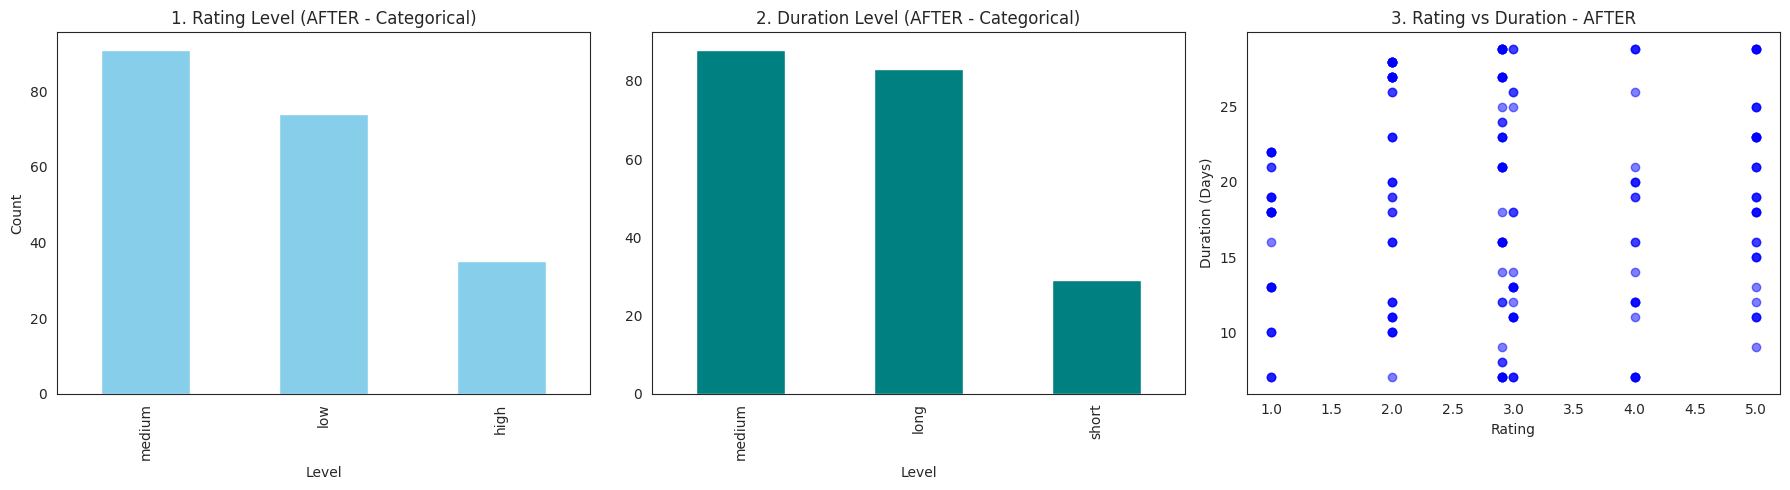

In [24]:
# --- VISUALIZATION: AFTER PREPROCESSING(3 Graphs) ---
plt.figure(figsize=(18, 5))

# Graph 1: Rating Level (Transformed Category)
plt.subplot(1, 3, 1)
integrated_df['RatingLevel'].value_counts().plot(kind='bar', color='skyblue')
plt.title("1. Rating Level (AFTER - Categorical)")
plt.xlabel("Level")
plt.ylabel("Count")

# Graph 2: Borrow Duration Level (Transformed Category)
plt.subplot(1, 3, 2)
integrated_df['BorrowDurationLevel'].value_counts().plot(kind='bar', color='teal')
plt.title("2. Duration Level (AFTER - Categorical)")
plt.xlabel("Level")

# Graph 3: User Rating vs Duration (Cleaned Scatter)
plt.subplot(1, 3, 3)
plt.scatter(integrated_df['UserRating_x'], integrated_df['BorrowDurationDays'], color='blue', alpha=0.5)
plt.title("3. Rating vs Duration - AFTER")
plt.xlabel("Rating")
plt.ylabel("Duration (Days)")

plt.tight_layout()
plt.show()